#  Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/raw_listings.csv')

In [ ]:
import pandas as pd
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

print("Downloading ALL data from Supabase...")
df = pd.read_sql("SELECT * FROM cars", engine)

# Fill missing condition/title_status with 'unspecified'
df['condition'] = df['condition'].fillna('unspecified')
df['title_status'] = df['title_status'].fillna('unspecified')

# Only keep cars that the LLM has successfully processed!
df = df[(df['trim'].notna()) & (df['trim'] != 'Error') & (df['make'].notna())]

print(f"Downloaded {len(df)} LLM-enriched cars!")
df.head()

trim
Base           1110
Sport            56
Touring          22
Luxury            5
Performance       2
Off-Road          1
Name: count, dtype: int64
Downloaded 16945 total cars!


,name,url,price,mileage,location,make,year,model,age,predicted_price,difference,condition,title_status,trim
0,2021 Audi I Q5 Plug-In Hybrid,https://www.craigslist.org/view/d/orinda-2021-...,28800,67000.0,lafayette,Audi,2021,Q5,5,23685.80,-5114.207031,excellent,clean,Base
1,2005 Volvo S40 – 117K Miles,https://www.craigslist.org/view/d/oakland-2005...,3900,118000.0,alameda,Volvo,2005,S40,21,5253.68,1353.682617,good,salvage,Base
2,2018 Infiniti G50 Luxury,https://www.craigslist.org/view/d/fairfield-20...,8900,110000.0,fairfield,Infiniti,2018,G50,8,11903.50,3003.505859,unspecified,unspecified,Luxury
3,2015 Mercedes-Benz C250 Sport,https://www.craigslist.org/view/d/roswell-2015...,9900,82000.0,roswell,Mercedes-Benz,2015,C250,11,13997.60,4097.647461,unspecified,clean,Sport
4,For Sale 1967 Amc Rambler,https://www.craigslist.org/view/d/santa-cruz-f...,1500,200000.0,santacruz,Amc,1967,Rambler,59,15743.80,14243.843750,fair,clean,Base


In [3]:
df.sample(10)

,name,url,price,mileage,location,make,year,model,age,predicted_price,difference,condition,title_status,trim
6805,1971 Dodge Demon 340 4 Speed,https://www.craigslist.org/view/d/hialeah-1971...,15000,123000.0,miami lakes,Dodge,1971,Other,55,18432.60,3432.607422,unspecified,unspecified,NaN
11440,2014 Volkswagen Passat 1.8T Se Sedan,https://www.craigslist.org/view/d/bridgeview-2...,5500,102000.0,bridgeview,Volkswagen,2014,Passat,12,7046.24,1546.237305,unspecified,unspecified,NaN
16294,*Updated* 2009 Bmw 535I With All Packages Incl...,https://www.craigslist.org/view/d/san-jose-upd...,3390,289000.0,san jose north,Bmw,2009,535I,17,4052.39,662.391846,good,salvage,NaN
15360,1996 Toyota Rav4,https://www.craigslist.org/view/d/atlanta-1996...,2500,213000.0,doraville,Toyota,1996,Rav4,30,3910.26,1410.256836,unspecified,unspecified,NaN
3016,2007 Hyundai Sonata / Azera 83 K Milles Clean ...,https://www.craigslist.org/view/d/maspeth-2007...,4950,87000.0,queens ny,Hyundai,2007,Sonata,19,5031.16,81.156250,like new,clean,NaN
3657,"Wtb, 1972-80 Chevy Luv",https://www.craigslist.org/view/d/bellevue-wtb...,12345,90000.0,eastside,Chevrolet,1972,Other,54,16118.10,3773.132812,unspecified,unspecified,NaN
2821,2019 Jaguar F-Pace S V6,https://www.craigslist.org/view/d/brooklyn-201...,16995,106000.0,brooklyn,Jaguar,2019,Fpace,7,12715.40,-4279.574219,unspecified,unspecified,NaN
14720,"Pristine 2011 Volkswagen Jetta Se - One Owner,...",https://www.craigslist.org/view/d/san-francisc...,4500,87000.0,marina,Volkswagen,2011,Jetta,15,7534.20,3034.195801,unspecified,unspecified,NaN
10027,2015 Ford F150 Supercab V6,https://www.craigslist.org/view/d/los-angeles-...,6900,23000.0,los angeles,Ford,2015,F150,11,15417.50,8517.471680,unspecified,unspecified,NaN
1966,Toyota Camry 1989,https://www.craigslist.org/view/d/south-gate-t...,6000,56000.0,south gate,Toyota,1989,Camry,37,11622.30,5622.255859,unspecified,clean,NaN


In [4]:
df.describe()

,price,mileage,year,age,predicted_price,difference
count,16945.000000,16945.000000,16945.000000,16945.000000,16945.00000,16945.000000
mean,10597.828858,127199.806374,2008.590145,17.409855,10333.06580,-264.762955
std,10572.758416,59696.436922,12.538629,12.538629,8058.55664,5926.214596
min,800.000000,100.000000,1922.000000,-1.000000,-2198.35000,-95546.713379
25%,4200.000000,87000.000000,2005.000000,10.000000,5083.30000,-1418.833008
50%,7350.000000,127000.000000,2011.000000,15.000000,7601.25000,366.762207
75%,12950.000000,168000.000000,2016.000000,21.000000,12816.90000,1886.001709
max,100000.000000,300000.000000,2027.000000,104.000000,90188.80000,34732.460938


# EDA & Data Cleaning

### Feature Cleaning: Location

In [5]:
df['location'] = df['location'].astype(str).str.split('/').str[0].str.lower().str.strip()

In [6]:
df.sample(10)

,name,url,price,mileage,location,make,year,model,age,predicted_price,difference,condition,title_status,trim
7152,Loved & Maintained 2005 Nissan 350Z Roadster C...,https://www.craigslist.org/view/d/atlanta-love...,3700,192000.0,atlanta,Nissan,2005,350Z,21,2797.02,-902.976074,unspecified,unspecified,NaN
9348,2011 Ford E450 Chassis,https://www.craigslist.org/view/d/spanaway-201...,1700,120000.0,tacoma,Ford,2011,Other,15,6557.01,4857.012207,unspecified,clean,NaN
16481,2000 Dodge Ram 1500 Quad Larmie Slt,https://www.craigslist.org/view/d/san-mateo-20...,5500,279000.0,san mateo,Dodge,2000,Ram 1500,26,4093.51,-1406.491211,good,clean,NaN
6971,1999 Honda Passport Ex-L Sport Utility,https://www.craigslist.org/view/d/atlanta-1999...,2500,270000.0,atlanta,Honda,1999,Passport,27,3681.66,1181.662842,unspecified,unspecified,NaN
6553,2015 Cadillac Ats 2.0 Turbo Luxury-Low Miles,https://www.craigslist.org/view/d/delray-beach...,8500,82000.0,delray bch,Cadillac,2015,Ats,11,11179.00,2678.959961,unspecified,unspecified,NaN
16374,2016 Ford Fusion Hybrid Plug In,https://www.craigslist.org/view/d/mountain-vie...,7499,138000.0,mountain view,Ford,2016,Fusion,10,7189.58,-309.417969,excellent,clean,NaN
7472,2012 Honda Accord Sport,https://www.craigslist.org/view/d/atlanta-2012...,2500,194000.0,city of atlanta,Honda,2012,Accord,14,4491.27,1991.269043,unspecified,unspecified,NaN
7615,2006 Bmw X5,https://www.craigslist.org/view/d/covington-20...,1200,157000.0,otp east,Bmw,2006,X5,20,4635.58,3435.576660,unspecified,unspecified,NaN
7266,2017 Audi A4 Allroad Premium Plus Wagon,https://www.craigslist.org/view/d/atlanta-2017...,15900,102000.0,sandy springs,Audi,2017,A4,9,11672.70,-4227.307617,unspecified,unspecified,NaN
3356,2010 Volkswagen Passat Wagon,https://www.craigslist.org/view/d/sayreville-2...,5500,93000.0,new jersey,Volkswagen,2010,Passat,16,6473.27,973.268066,good,clean,NaN


### Univariate Analysis & Outliers

In [7]:
print(df[['price', 'mileage']].describe())

               price        mileage
count   16945.000000   16945.000000
mean    10597.828858  127199.806374
std     10572.758416   59696.436922
min       800.000000     100.000000
25%      4200.000000   87000.000000
50%      7350.000000  127000.000000
75%     12950.000000  168000.000000
max    100000.000000  300000.000000


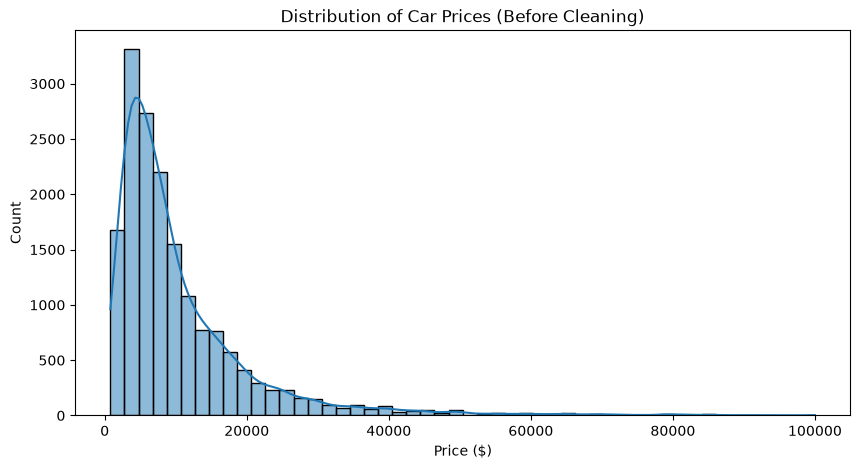

In [8]:
# Plot price distribution

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (Before Cleaning)')
plt.xlabel('Price ($)')
plt.show()

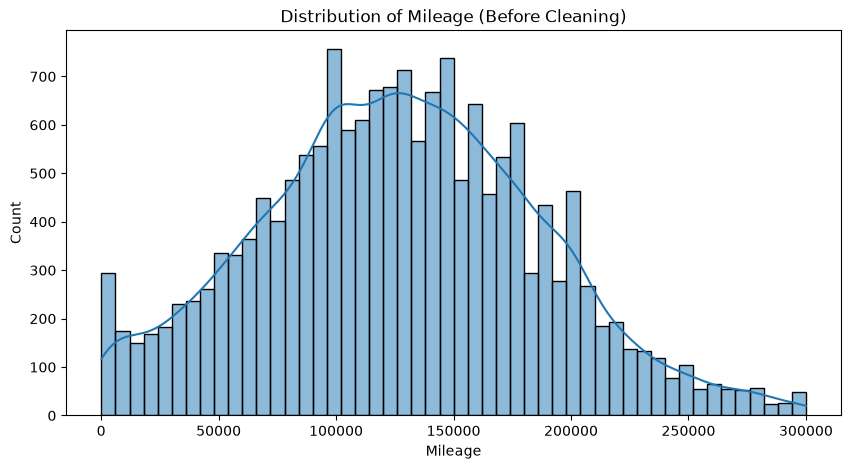

In [9]:
# Plot Mileage distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (Before Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [10]:
# 1. Define the realistic bounds for vehicles
MIN_PRICE = 800
MAX_PRICE = 100000
MIN_MILEAGE = 100
MAX_MILEAGE = 300000

# 2. Filter the DataFrame
df_clean = df[
    (df['price'] >= MIN_PRICE) & 
    (df['price'] <= MAX_PRICE) &
    (df['mileage'] >= MIN_MILEAGE) & 
    (df['mileage'] <= MAX_MILEAGE)
].copy()

# Drop any remaining rows where mileage or price might be NaN
df_clean = df_clean.dropna(subset=['price', 'mileage'])

print(f"Rows before trimming: {len(df)}")
print(f"Rows after trimming: {len(df_clean)}")

# New mathematical summary
print(df_clean[['price', 'mileage']].describe())

Rows before trimming: 16945
Rows after trimming: 16945
               price        mileage
count   16945.000000   16945.000000
mean    10597.828858  127199.806374
std     10572.758416   59696.436922
min       800.000000     100.000000
25%      4200.000000   87000.000000
50%      7350.000000  127000.000000
75%     12950.000000  168000.000000
max    100000.000000  300000.000000


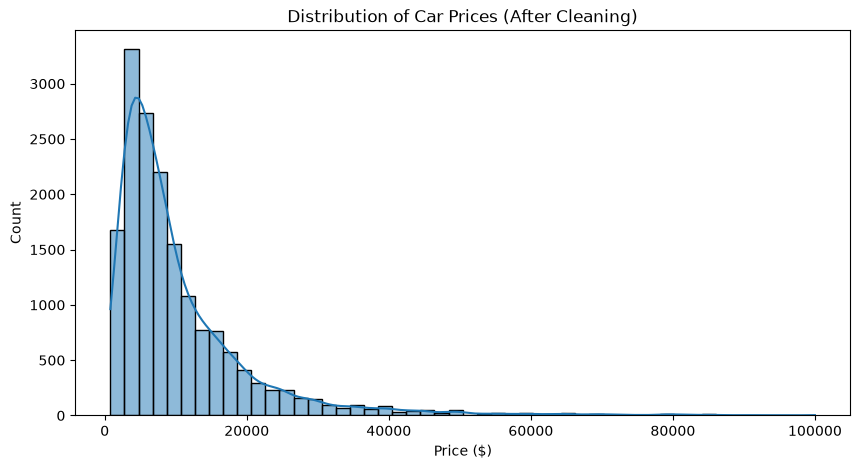

In [11]:
# Plot price distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (After Cleaning)')
plt.xlabel('Price ($)')
plt.show()

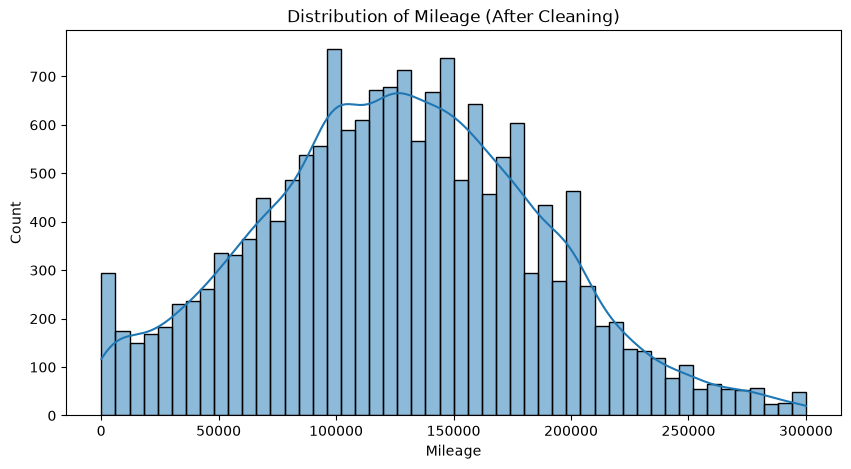

In [12]:
# Plot Mileage distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (After Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [13]:
import re

# Extract Year (Looks for 19xx or 20xx)
df_clean['year'] = df_clean['name'].str.extract(r'(\b(19[0-9]{2}|20[0-2][0-9])\b)')[0]

# Drop rows that didn't have a year in the title
df_clean = df_clean.dropna(subset=['year'])
df_clean['year'] = df_clean['year'].astype(int)

df_clean

,name,url,price,mileage,location,make,year,model,age,predicted_price,difference,condition,title_status,trim
0,2021 Audi I Q5 Plug-In Hybrid,https://www.craigslist.org/view/d/orinda-2021-...,28800,67000.0,lafayette,Audi,2021,Q5,5,23685.80,-5114.207031,excellent,clean,Base
1,2005 Volvo S40 – 117K Miles,https://www.craigslist.org/view/d/oakland-2005...,3900,118000.0,alameda,Volvo,2005,S40,21,5253.68,1353.682617,good,salvage,Base
2,2018 Infiniti G50 Luxury,https://www.craigslist.org/view/d/fairfield-20...,8900,110000.0,fairfield,Infiniti,2018,G50,8,11903.50,3003.505859,unspecified,unspecified,Luxury
3,2015 Mercedes-Benz C250 Sport,https://www.craigslist.org/view/d/roswell-2015...,9900,82000.0,roswell,Mercedes-Benz,2015,C250,11,13997.60,4097.647461,unspecified,clean,Sport
4,For Sale 1967 Amc Rambler,https://www.craigslist.org/view/d/santa-cruz-f...,1500,200000.0,santacruz,Amc,1967,Rambler,59,15743.80,14243.843750,fair,clean,Base
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16940,2004 Jeep Wrangler X – Fully Built,https://www.craigslist.org/view/d/burbank-2004...,13700,73000.0,san fernando valley,Jeep,2004,Wrangler,22,13233.40,-466.627930,unspecified,unspecified,NaN
16941,1999 Mercedes C230 Kompressor (Not Running),https://www.craigslist.org/view/d/pasadena-199...,1500,200000.0,central la 213,Mercedes,1999,C230,27,3746.72,2246.715576,unspecified,clean,NaN
16942,2014 Nissan Frontier Sv,https://www.craigslist.org/view/d/chatsworth-2...,12500,117000.0,san fernando valley,Nissan,2014,Frontier,12,9728.63,-2771.366211,unspecified,unspecified,NaN
16943,2008 Ford F-250Xl Super Duty Extended Cab 5.4L...,https://www.craigslist.org/view/d/gardena-2008...,9500,73000.0,westside-southbay-310,Ford,2008,F-250Xl Super Duty,18,12953.80,3453.757812,unspecified,unspecified,NaN


In [14]:
import datetime

# Get the current year
current_year = datetime.datetime.now().year

# Calculate age
df_clean['age'] = current_year - df_clean['year']

# Quick check
print(df_clean[['name', 'year', 'age']].head())

                            name  year  age
0  2021 Audi I Q5 Plug-In Hybrid  2021    5
1    2005 Volvo S40 – 117K Miles  2005   21
2       2018 Infiniti G50 Luxury  2018    8
3  2015 Mercedes-Benz C250 Sport  2015   11
4      For Sale 1967 Amc Rambler  1967   59


In [15]:
# Drop rows missing the core LLM-enriched features
df_clean = df_clean.dropna(subset=['price', 'mileage', 'year', 'make', 'model', 'trim'])
print(f"Rows after final cleaning: {len(df_clean)}")

Rows after final cleaning: 1196


In [16]:
df_clean.to_csv('../data/clean_listings.csv', index=False)

# Model Training & Evaluation

* Split data into Train (80%) and Test (20%).
* Apply One-Hot Encoding to categorical data (Make, Location).
* Train an XGBoost Regression model.

In [17]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [18]:
# 1. Define Features (X) and Target (y) and perform train_test_split

X = df_clean[['age', 'make', 'model', 'trim', 'mileage', 'location', 'condition', 'title_status']]
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = ohe.fit_transform(X_train[['make', 'model', 'trim', 'location', 'condition', 'title_status']])
X_test_encoded = ohe.transform(X_test[['make', 'model', 'trim', 'location', 'condition', 'title_status']])

# Put the encoded arrays back into DataFrames so they have column names
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(), index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(), index=X_test.index)

# Drop the original text columns, keep only numbers (age, mileage)
X_train_num = X_train.drop(columns=['make', 'model', 'trim', 'location', 'condition', 'title_status'])
X_test_num = X_test.drop(columns=['make', 'model', 'trim', 'location', 'condition', 'title_status'])

# Combine the numerical columns and encoded columns together
X_train_final = pd.concat([X_train_num, X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test_num, X_test_encoded_df], axis=1)

print(f"Training data shape: {X_train_final.shape}")
print(f"Testing data shape: {X_test_final.shape}")

Training data shape: (956, 711)
Testing data shape: (240, 711)


## Train the Model

In [20]:
# Diagnostic check: What columns is the model actually seeing?
print("Columns being fed to the model:")
print(X_train_final.columns.tolist())

print("\nFirst 3 rows of training data:")
X_train_final.head(3)

Columns being fed to the model:
['age', 'mileage', 'make_Acura', 'make_Amc', 'make_Audi', 'make_Bentley', 'make_Bmw', 'make_Buick', 'make_Cadillac', 'make_Chevrolet', 'make_Chevy', 'make_Chrysler', 'make_Dodge', 'make_Ford', 'make_Gmc', 'make_Honda', 'make_Hyundai', 'make_Infiniti', 'make_Jaguar', 'make_Jeep', 'make_Kia', 'make_Land Rover', 'make_Lexus', 'make_Mazda', 'make_Mercedes', 'make_Mercedes Benz', 'make_Mercedes Freightliner', 'make_Mercedes-Benz', 'make_Mercedez Benz', 'make_Mini', 'make_Mitsubishi', 'make_Nissan', 'make_Pontiac', 'make_Porsche', 'make_Ram', 'make_Saturn', 'make_Subaru', 'make_Tesla', 'make_Toyota', 'make_Volkswagen', 'make_Volvo', 'make_Vw', 'model_1500', 'model_1962', 'model_2', 'model_2 Door Sedan', 'model_200', 'model_2002', 'model_2005', 'model_2016', 'model_240D', 'model_2500', 'model_2500 Pickup Truck', 'model_250Sl', 'model_280C', 'model_3', 'model_3/4 Ton Crew Cab', 'model_300', 'model_300E', 'model_300Sd', 'model_3100', 'model_320I', 'model_325', 'm

,age,mileage,make_Acura,make_Amc,make_Audi,make_Bentley,make_Bmw,make_Buick,make_Cadillac,make_Chevrolet,...,condition_like new,condition_new,condition_salvage,condition_unspecified,title_status_clean,title_status_lien,title_status_missing,title_status_rebuilt,title_status_salvage,title_status_unspecified
821,11,64000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
116,19,194000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1529,8,150000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [21]:
# Tuned XGBoost Model
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True, # Enables native categorical partitioning
    random_state=42
)  

# Train the model!
model.fit(X_train_final, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [22]:
# Make predictions on our test set
predictions = model.predict(X_test_final)

# Calculate Mean Absolute Error (MAE) and R-Squared
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Model Performance:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-Squared (R2): {r2:.2f}")

# Visually compare actual vs predicted for the first 10 cars
comparison = pd.DataFrame({
    'Actual_Price': y_test.values[:10],
    'Predicted_Price': predictions[:10].astype(int),
    'Age': X_test['age'].values[:10],
    'Make': X_test['make'].values[:10],
    'Model': X_test['model'].values[:10],
    'Trim': X_test['trim'].values[:10],
    'Mileage': X_test['mileage'].values[:10]
})
print("\nSample Predictions vs Actuals:")
print(comparison)

Model Performance:
Mean Absolute Error (MAE): $3,801.19
R-Squared (R2): 0.40

Sample Predictions vs Actuals:
   Actual_Price  Predicted_Price  Age           Make       Model  Trim  \
0          7000             5529   10        Hyundai      Sonata  Base   
1          6999             5680   23  Mercedes-Benz        S500  Base   
2          2500             3372   16          Honda      Accord  Base   
3         29499            29642    4       Mercedes        C300  Base   
4          5500             5733   12            Bmw          X1  Base   
5          2850             4370   14         Nissan       Versa  Base   
6          9500            11051   35          Chevy  S10 Pickup  Base   
7         12000            19908    8           Ford      Fiesta  Base   
8          1400             2854   23          Honda     Odyssey  Base   
9         22800            28489    7          Honda       Civic  Base   

    Mileage  
0  173000.0  
1   82000.0  
2  132000.0  
3   43000.0  
4  183

# Export the model using Pickle

In [23]:
import joblib
import os

os.makedirs('../api', exist_ok=True)

# Save the XGBoost model
joblib.dump(model, '../api/model.pkl')

# Save the One-Hot Encoder
joblib.dump(ohe, '../api/ohe.pkl')

print("Model and Encoder saved successfully to the api/ folder!")

Model and Encoder saved successfully to the api/ folder!


In [24]:
# Save the exact column order from the final training dataframe
joblib.dump(X_train_final.columns.tolist(), '../api/model_columns.pkl')
print("Saved model_columns.pkl!")

Saved model_columns.pkl!
